In [94]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import pandas_datareader as data
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")


In [95]:
start = '2015-01-01'
end = '2025-11-13'

df = yf.download('SBIN.NS', start=start, end=end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
Date,,,,,
2015-01-01,279.880554,280.771894,276.939145,278.498989,6138488
2015-01-02,280.994720,283.713295,280.192521,280.192521,9935094
2015-01-05,278.766388,282.376302,278.187023,281.886076,9136716
2015-01-06,267.312622,277.295632,266.243031,276.315153,15329257
2015-01-07,267.535461,269.674670,263.078765,267.401766,15046745


In [96]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
Date,,,,,
2025-11-06,960.750000,971.400024,955.299988,969.650024,23088096
2025-11-07,955.849976,964.849976,944.000000,958.750000,13371323
2025-11-10,951.150024,963.200012,949.099976,956.000000,7343249
2025-11-11,953.299988,954.950012,945.049988,953.599976,8648917
2025-11-12,957.150024,961.549988,951.400024,957.700012,7043323


In [97]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
0,2015-01-01,279.880554,280.771894,276.939145,278.498989,6138488
1,2015-01-02,280.994720,283.713295,280.192521,280.192521,9935094
2,2015-01-05,278.766388,282.376302,278.187023,281.886076,9136716
3,2015-01-06,267.312622,277.295632,266.243031,276.315153,15329257
4,2015-01-07,267.535461,269.674670,263.078765,267.401766,15046745


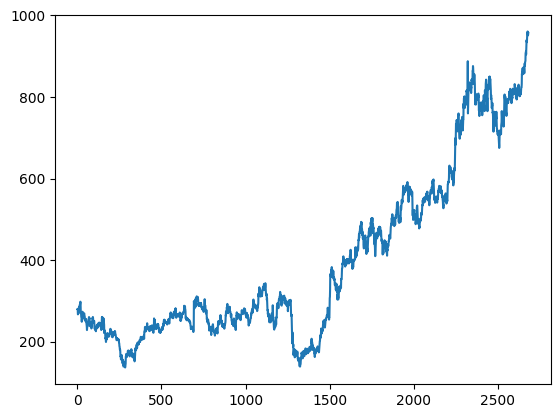

In [98]:
plt.plot(df.Close)
plt.show()

In [99]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
0,2015-01-01,279.880554,280.771894,276.939145,278.498989,6138488
1,2015-01-02,280.994720,283.713295,280.192521,280.192521,9935094
2,2015-01-05,278.766388,282.376302,278.187023,281.886076,9136716
3,2015-01-06,267.312622,277.295632,266.243031,276.315153,15329257
4,2015-01-07,267.535461,269.674670,263.078765,267.401766,15046745
...,...,...,...,...,...,...
2678,2025-11-06,960.750000,971.400024,955.299988,969.650024,23088096
2679,2025-11-07,955.849976,964.849976,944.000000,958.750000,13371323
2680,2025-11-10,951.150024,963.200012,949.099976,956.000000,7343249


In [100]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,SBIN.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2678,839.257501
2679,840.891000
2680,842.479501
2681,844.093500


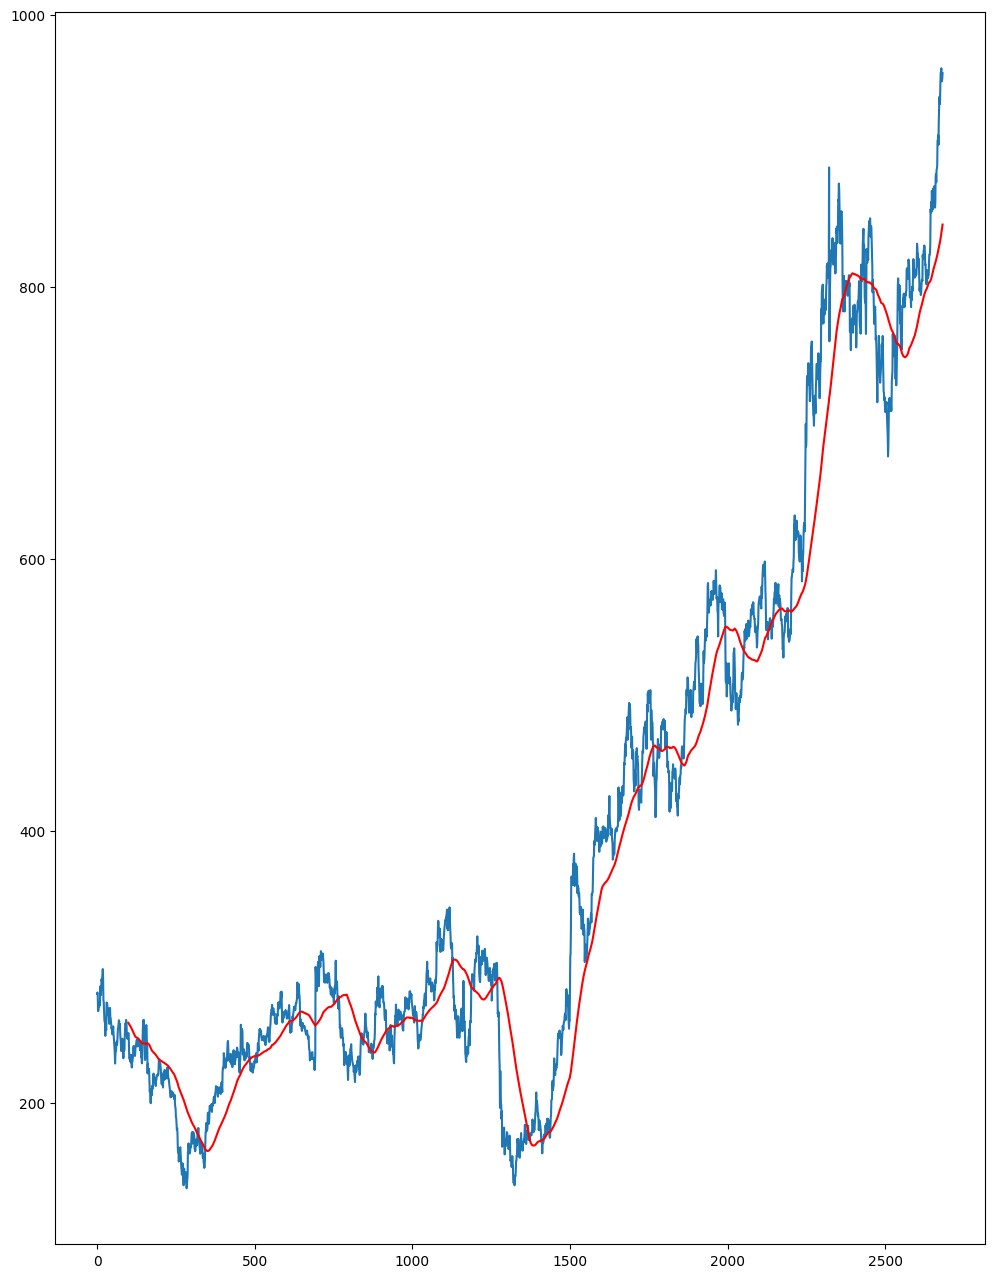

In [101]:
plt.figure(figsize = (12,16))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.show()

In [102]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,SBIN.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2678,797.364853
2679,798.398806
2680,799.335002
2681,800.380959


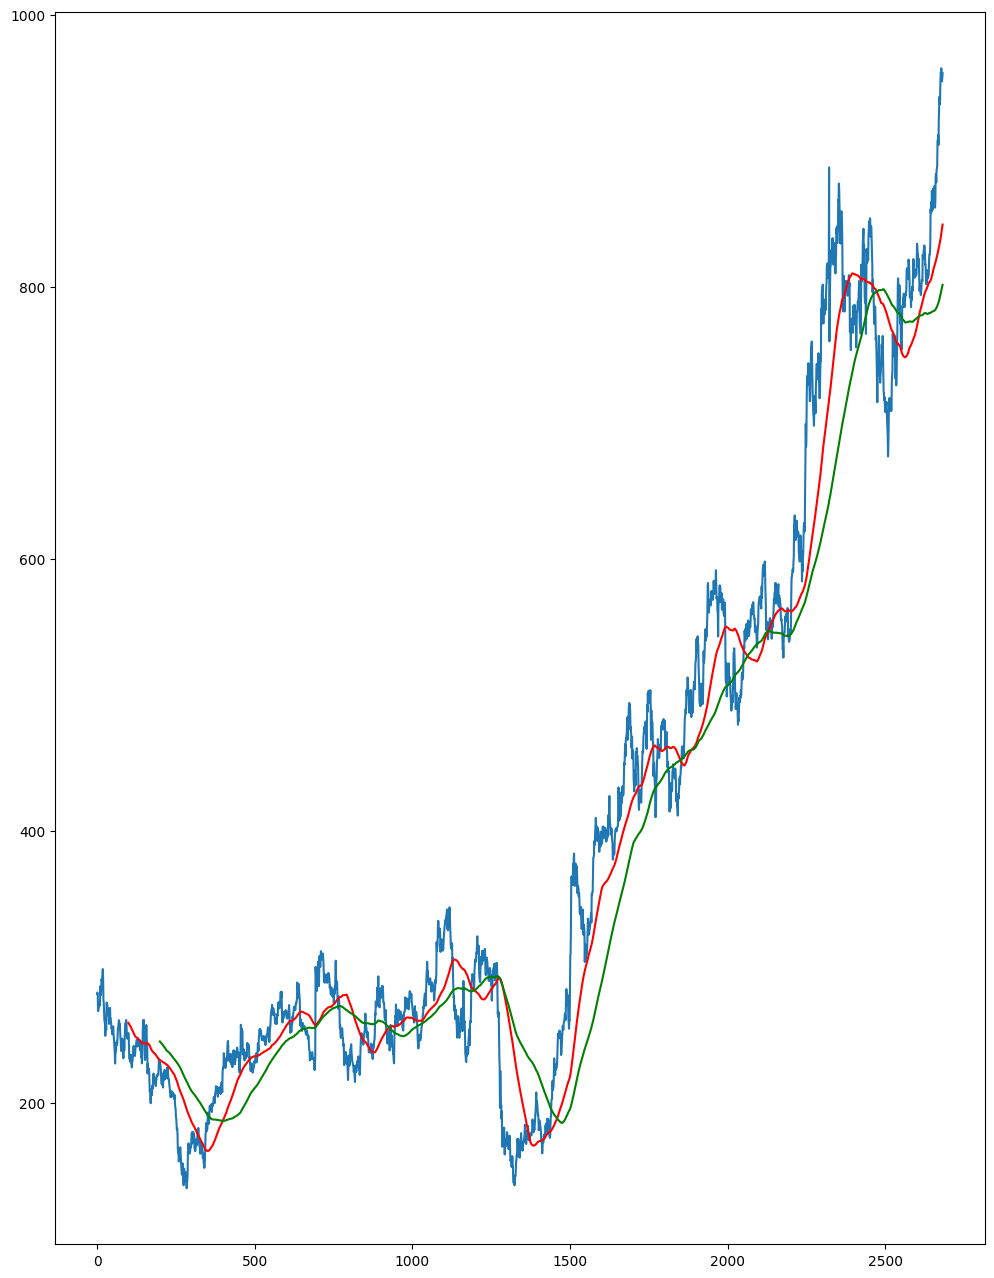

In [103]:
plt.figure(figsize = (12,16))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.show()

In [104]:
df.shape

(2683, 6)

In [105]:
#spliting data into training & testing
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])
print(data_training.shape)
print(data_testing.shape)

(1878, 1)
(805, 1)


In [106]:
data_training.head(10)

Ticker,SBIN.NS
0,279.880554
1,280.994720
2,278.766388
3,267.312622
4,267.535461
5,271.724792
6,270.254089
7,273.730286
8,271.947601
9,271.591125


In [107]:
data_training.tail(10)

Ticker,SBIN.NS
1868,486.314209
1869,499.554962
1870,503.574524
1871,499.696808
1872,504.803986
1873,512.701172
1874,511.518890
1875,504.331146
1876,502.250427
1877,492.177979


In [108]:
data_testing.head(10)

Ticker,SBIN.NS
1878,486.787079
1879,496.292084
1880,501.919373
1881,497.427002
1882,499.507721
1883,503.479889
1884,492.130646
1885,483.571472
1886,493.596649
1887,491.137634


In [109]:
data_testing.tail(10)

Ticker,SBIN.NS
2673,934.349976
2674,937.000000
2675,949.700012
2676,957.599976
2677,957.599976
2678,960.750000
2679,955.849976
2680,951.150024
2681,953.299988
2682,957.150024


In [110]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [111]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.38028162],
       [0.38324729],
       [0.37731595],
       ...,
       [0.97772079],
       [0.97218237],
       [0.94537168]], shape=(1878, 1))

In [112]:
x_train = []
y_train = []
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

In [113]:
x_train.shape

(1778, 100, 1)

In [114]:
#ML Model
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [117]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

In [118]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 243ms/step - loss: 0.0420
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - loss: 0.0113
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 234ms/step - loss: 0.0092
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - loss: 0.0076
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 229ms/step - loss: 0.0076
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 229ms/step - loss: 0.0068
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 229ms/step - loss: 0.0063
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 230ms/step - loss: 0.0062
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 238ms/step - loss: 0.0055
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 225ms/step - loss: 0.0056
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 229ms/step - loss: 0.0048
Epoch 12/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 230ms/step - loss: 0.0050
Epoch 13/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - loss: 0.0045
Epoch 14/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - loss: 0.0056
Epoch 15/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 

In [121]:
model.save('keras_model.h5')

In [122]:
data_testing.head()

Ticker,SBIN.NS
1878,486.787079
1879,496.292084
1880,501.919373
1881,497.427002
1882,499.507721


In [123]:
past_100_days = data_training.tail(100)

In [125]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [126]:
final_df.head()

Ticker,SBIN.NS
0,458.866333
1,467.387177
2,456.864166
3,459.751038
4,456.910767


In [127]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.08686058],
       [0.10236361],
       [0.08321779],
       [0.08847024],
       [0.08330258],
       [0.07728773],
       [0.08338731],
       [0.09490863],
       [0.09067283],
       [0.08948678],
       [0.08821599],
       [0.11303774],
       [0.12015392],
       [0.11507088],
       [0.12278006],
       [0.12447438],
       [0.12642274],
       [0.12438971],
       [0.12091621],
       [0.12913377],
       [0.11524039],
       [0.11913727],
       [0.11490147],
       [0.1267616 ],
       [0.10016096],
       [0.09024924],
       [0.10846314],
       [0.09448503],
       [0.11185174],
       [0.09287543],
       [0.08389558],
       [0.06466514],
       [0.06525808],
       [0.07195072],
       [0.05831142],
       [0.05712542],
       [0.05941269],
       [0.03586178],
       [0.00536416],
       [0.02290027],
       [0.04374037],
       [0.0279832 ],
       [0.0101929 ],
       [0.03543824],
       [0.03289672],
       [0.03484519],
       [0.03338256],
       [0.058

In [128]:
input_data.shape

(905, 1)

In [129]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(805, 100, 1)
(805,)


In [130]:
#Making Predictions
y_predicted = model.predict(x_test)
y_predicted.shape

26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step


(805, 1)

In [132]:
y_test

array([0.13766027, 0.15495391, 0.16519234, 0.15701881, 0.16080452,
       0.16803158, 0.14738249, 0.13180972, 0.15004977, 0.14557578,
       0.14746861, 0.1533191 , 0.1379184 , 0.16613875, 0.16966627,
       0.17551688, 0.17930259, 0.17740965, 0.16889204, 0.18919688,
       0.20416737, 0.20683466, 0.212169  , 0.23582929, 0.23651768,
       0.21870778, 0.23668981, 0.23978707, 0.23230182, 0.22817203,
       0.19943536, 0.18687385, 0.17517274, 0.15512587, 0.14979164,
       0.16502021, 0.14635007, 0.16863391, 0.1765493 , 0.16433198,
       0.1652784 , 0.15951391, 0.17052668, 0.14927543, 0.15916966,
       0.18747618, 0.21982626, 0.20425355, 0.20769506, 0.21707314,
       0.23367839, 0.24753051, 0.24942323, 0.23410848, 0.23935687,
       0.24469121, 0.23944293, 0.25845738, 0.2740301 , 0.30878939,
       0.31119826, 0.29433505, 0.28667756, 0.27162112, 0.28590322,
       0.28401039, 0.28280596, 0.28908666, 0.28117121, 0.28289202,
       0.29760444, 0.30052969, 0.29717423, 0.29923908, 0.29915

In [133]:
y_predicted

array([[0.20640212],
       [0.20506212],
       [0.20177531],
       [0.19767949],
       [0.19364476],
       [0.19033879],
       [0.18830732],
       [0.18706545],
       [0.18568927],
       [0.18410829],
       [0.18240899],
       [0.18081078],
       [0.1796853 ],
       [0.17877191],
       [0.17866048],
       [0.17986892],
       [0.18259451],
       [0.18665853],
       [0.19146262],
       [0.19603145],
       [0.20028855],
       [0.20471045],
       [0.20951813],
       [0.21475127],
       [0.22081986],
       [0.22766113],
       [0.23423296],
       [0.2401411 ],
       [0.24517943],
       [0.24911982],
       [0.2517632 ],
       [0.252441  ],
       [0.2506823 ],
       [0.24620295],
       [0.23891288],
       [0.22916603],
       [0.21815214],
       [0.20685986],
       [0.19689621],
       [0.18974587],
       [0.18558973],
       [0.18404698],
       [0.18423037],
       [0.18566778],
       [0.18724418],
       [0.1884953 ],
       [0.19019456],
       [0.194

In [134]:
scaler.scale_

array([0.00181942])

In [135]:
scale_factor = 1/0.00181942
y_predicted = y_predicted * scale_factor
y_test = y_test*scale_factor

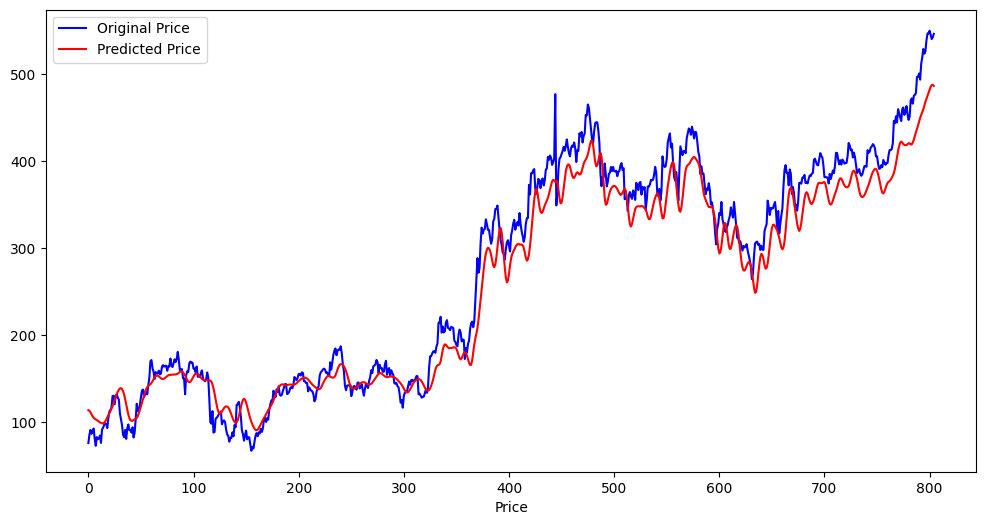

In [136]:
plt.figure(figsize = (12,6))
plt.plot(y_test,'b', label = 'Original Price')
plt.plot(y_predicted, 'r', label = 'Predicted Price')
plt.xlabel('Price')
plt.legend()
plt.show()